In [42]:
# pip install tabulate


### Importing packages

In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
import glob
import pickle
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import pandas as pd
from tabulate import tabulate
from sklearn.utils import resample
from sklearn.metrics import precision_recall_curve



    
#!ls 'D:/project/videos'
framesPath = 'D:/project/frames'
videosPath = 'D:/project/videos'


#### Extracting framses from the video

In [2]:
def extract_frames(video_path, output_dir, frame_rate=30):
    """
    Extracts frames from a video and saves them in the specified directory.

    Parameters:
        video_path (str): Path to the video file.
        output_dir (str): Directory to save the frames.
        frame_rate (int): Extract 1 frame every `frame_rate` seconds.
    """

    os.makedirs(output_dir, exist_ok=True)

    # Open the video file
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))  # Video frame rate
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Processing {video_path}: {total_frames} frames at {fps} FPS.")

    # Frame extraction
    frame_count = 0
    saved_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Save one frame every `frame_rate` seconds
        if frame_count % (fps / frame_rate) == 0:
            frame_name = os.path.join(output_dir, f"frame_{saved_count:05d}.jpg")
            cv2.imwrite(frame_name, frame)
            saved_count += 1
        frame_count += 1

    cap.release()
    print(f"Saved {saved_count} frames to {output_dir}")


# Sample code for extracting frames from a video file
# # for video_file in os.listdir(video_dir):
# video_path = os.path.join(video_dir, "Arrest030_x264.mp4")
# video_output = os.path.join(output_dir, 'Arrest030_x264')
# extract_frames(video_path, video_output)




## Batch process the frame extraction for all videos.

In [3]:
video_dir = videosPath
output_dir = framesPath


# Extract frames from all videos in the directory ( Run this code if the frames are not extracted yet)
for video_file in os.listdir(video_dir):
    video_path = os.path.join(video_dir, video_file)
    video_output = os.path.join(output_dir, video_file.split(".")[0])
    extract_frames(video_path, video_output)


Processing D:/project/videos\Abuse028_x264.mp4: 1412 frames at 30 FPS.
Saved 1412 frames to D:/project/frames\Abuse028_x264
Processing D:/project/videos\Abuse030_x264.mp4: 1544 frames at 30 FPS.
Saved 1544 frames to D:/project/frames\Abuse030_x264
Processing D:/project/videos\Arrest001_x264.mp4: 2374 frames at 30 FPS.
Saved 2374 frames to D:/project/frames\Arrest001_x264
Processing D:/project/videos\Arrest007_x264.mp4: 3144 frames at 30 FPS.
Saved 3144 frames to D:/project/frames\Arrest007_x264
Processing D:/project/videos\Arrest024_x264.mp4: 3629 frames at 30 FPS.
Saved 3629 frames to D:/project/frames\Arrest024_x264
Processing D:/project/videos\Arrest030_x264.mp4: 8642 frames at 30 FPS.
Saved 8642 frames to D:/project/frames\Arrest030_x264
Processing D:/project/videos\Arrest039_x264.mp4: 15835 frames at 30 FPS.
Saved 15835 frames to D:/project/frames\Arrest039_x264
Processing D:/project/videos\Arson016_x264.mp4: 1795 frames at 30 FPS.
Saved 1795 frames to D:/project/frames\Arson016_x

Testing a sample frame extracted from the videos.

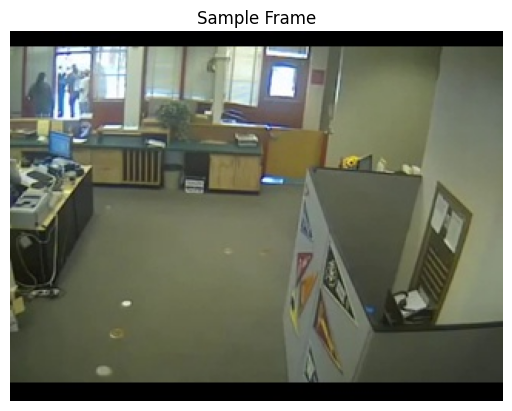

In [4]:
frame_path = framesPath + "/Arrest001_x264/frame_00090.jpg" 

# Check if the file exists
if os.path.exists(frame_path):
	frame = cv2.imread(frame_path)
	# Display the frame
	plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
	plt.axis('off')
	plt.title("Sample Frame")
	plt.show()
else:
	print(f"File not found: {frame_path}")


#### Preprocessing the frmaes 

In [5]:
def preprocess_frame(frame_path, size=(64, 64)):
    frame = cv2.imread(frame_path)
    frame = cv2.resize(frame, size)  # Resize to model input size
    frame = frame.astype('float32')/ 255.0  # Normalize pixel values to [0, 1]
    return frame


frame = preprocess_frame(frame_path)

In [6]:
def batch_process_frames(frames_path, output_dir):
    """
    Batch process all frames for all videos in the frames directory.
    Args:
        frames_path (str): Path to the directory containing frames for all videos.
        output_dir (str): Directory to save preprocessed frames (optional).
    """
    os.makedirs(output_dir, exist_ok=True)

    # Loop through each video folder
    for video_folder in os.listdir(frames_path):
        video_dir = os.path.join(frames_path, video_folder)

        if not os.path.isdir(video_dir):
            continue  # Skip non-directory files

        print(f"Processing video: {video_folder}")

        # Get all frames for this video
        frames = sorted(glob.glob(f"{video_dir}/*.jpg"))
        if len(frames) == 0:
            print(f"No frames found in: {video_dir}")
            continue

        # Preprocess all frames
        preprocessed_frames = [preprocess_frame(f) for f in frames]

        # Save preprocessed frames if needed
        video_output_dir = os.path.join(output_dir, video_folder)
        os.makedirs(video_output_dir, exist_ok=True)

        for i, frame in enumerate(preprocessed_frames):
            output_path = os.path.join(video_output_dir, f"frame_{i:05d}.jpg")
            cv2.imwrite(output_path, (frame * 255).astype("uint8"))  # Save normalized frame back to disk

        print(f"Processed {len(preprocessed_frames)} frames for {video_folder}")



# Directory to save preprocessed frames
batch_process_frames(framesPath, framesPath)

Processing video: Abuse028_x264
Processed 1412 frames for Abuse028_x264
Processing video: Abuse030_x264
Processed 1544 frames for Abuse030_x264
Processing video: Arrest001_x264
Processed 2374 frames for Arrest001_x264
Processing video: Arrest007_x264
Processed 3144 frames for Arrest007_x264
Processing video: Arrest024_x264
Processed 3629 frames for Arrest024_x264
Processing video: Arrest030_x264
Processed 8642 frames for Arrest030_x264
Processing video: Arrest039_x264
Processed 15835 frames for Arrest039_x264
Processing video: Arson016_x264
Processed 1795 frames for Arson016_x264
Processing video: Arson041_x264
Processed 3754 frames for Arson041_x264
Processing video: Assault006_x264
Processed 8096 frames for Assault006_x264
Processing video: Assault010_x264
Processed 16177 frames for Assault010_x264
Processing video: Assault011_x264
Processed 2288 frames for Assault011_x264
Processing video: Assault045_x264
Processed 1119 frames for Assault045_x264
Processing video: Burglary005_x264
P

### Creating sequences for each frame extracted form the videos.

In [7]:
def create_sequences(frame_dir, sequence_length=16):
    """
    Create sequences of frames for spatio-temporal models.

    Parameters:
        frame_dir (str): Path to the directory containing extracted frames.
        sequence_length (int): Number of frames per sequence.

    Returns:
        list: A list of sequences, each sequence is a list of normalized frames.
    """
    frames = sorted(glob.glob(f"{frame_dir}/*.jpg"))  # Sort frames
    sequences = []
    for i in range(0, len(frames) - sequence_length + 1, sequence_length):
        sequence = [cv2.imread(f) / 255.0 for f in frames[i:i + sequence_length]]
        sequences.append(np.stack(sequence, axis=0))  # Stack frames into one array
    return sequences



# Example usage
frame_dir = framesPath + "/Abuse028_x264"
sequences = create_sequences(frame_dir)
print(f"Number of sequences: {len(sequences)}")


Number of sequences: 88


In [8]:
def batch_process_frames_to_sequences(input_dir, output_dir, sequence_length=16):
    """
    Batch process all frame folders to generate and save sequences.

    Parameters:
        input_dir (str): Path to the directory containing all frame folders.
        output_dir (str): Path to the directory where sequences will be saved.
        sequence_length (int): Number of frames per sequence.
    """
    os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

    for video_name in os.listdir(input_dir):
        video_frame_dir = os.path.join(input_dir, video_name)
        if os.path.isdir(video_frame_dir):  # Process only directories
            print(f"Processing: {video_name}")

            # Convert frames to sequences
            sequences = create_sequences(video_frame_dir, sequence_length=sequence_length)

            # Save sequences to a pickle file
            output_file = os.path.join(output_dir, f"{video_name}.pkl")
            with open(output_file, "wb") as f:
                pickle.dump(sequences, f)

            print(f"Saved {len(sequences)} sequences for {video_name} to {output_file}")
    return sequences

input_dir = framesPath # Path to all frame directories
output_dir = "D:/project/sequences"  # Path to save sequence files
sequences = batch_process_frames_to_sequences(input_dir, output_dir, sequence_length=16)


Processing: Abuse028_x264
Saved 88 sequences for Abuse028_x264 to D:/project/sequences\Abuse028_x264.pkl
Processing: Abuse030_x264
Saved 96 sequences for Abuse030_x264 to D:/project/sequences\Abuse030_x264.pkl
Processing: Arrest001_x264
Saved 148 sequences for Arrest001_x264 to D:/project/sequences\Arrest001_x264.pkl
Processing: Arrest007_x264
Saved 196 sequences for Arrest007_x264 to D:/project/sequences\Arrest007_x264.pkl
Processing: Arrest024_x264
Saved 226 sequences for Arrest024_x264 to D:/project/sequences\Arrest024_x264.pkl
Processing: Arrest030_x264
Saved 540 sequences for Arrest030_x264 to D:/project/sequences\Arrest030_x264.pkl
Processing: Arrest039_x264
Saved 989 sequences for Arrest039_x264 to D:/project/sequences\Arrest039_x264.pkl
Processing: Arson016_x264
Saved 112 sequences for Arson016_x264 to D:/project/sequences\Arson016_x264.pkl
Processing: Arson041_x264
Saved 234 sequences for Arson041_x264 to D:/project/sequences\Arson041_x264.pkl
Processing: Assault006_x264
Saved

### Parsing the Annotation file for labelling the sequences

In [9]:
def parse_annotation_file(annotation_file):
    """
    Parse annotations to get anomaly ranges for each video.
    """
    annotations = {}
    with open(annotation_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            video_name = parts[0]
            start_frame, end_frame = int(parts[2]), int(parts[3])
            annotations[video_name] = (start_frame, end_frame)
    return annotations

# Load annotations
annotation_file = "D:/project/annotations/Temporal_Anomaly_Annotation_for_Testing_Videos.txt"
annotations = parse_annotation_file(annotation_file)
print(annotations)


{'Abuse028_x264.mp4': (165, 240), 'Abuse030_x264.mp4': (1275, 1360), 'Arrest001_x264.mp4': (1185, 1485), 'Arrest007_x264.mp4': (1530, 2160), 'Arrest024_x264.mp4': (1005, 3105), 'Arrest030_x264.mp4': (5535, 7200), 'Arrest039_x264.mp4': (7215, 10335), 'Arson007_x264.mp4': (2250, 5700), 'Arson009_x264.mp4': (220, 315), 'Arson010_x264.mp4': (885, 1230), 'Arson011_x264.mp4': (150, 420), 'Arson016_x264.mp4': (1000, 1796), 'Arson018_x264.mp4': (270, 600), 'Arson022_x264.mp4': (3500, 4000), 'Arson035_x264.mp4': (600, 900), 'Arson041_x264.mp4': (2130, 3615), 'Assault006_x264.mp4': (1185, 8096), 'Assault010_x264.mp4': (11330, 11680), 'Assault011_x264.mp4': (375, 960), 'Burglary005_x264.mp4': (4710, 5040), 'Burglary017_x264.mp4': (150, 600), 'Burglary018_x264.mp4': (720, 1050), 'Burglary021_x264.mp4': (60, 200), 'Burglary024_x264.mp4': (60, 1230), 'Burglary032_x264.mp4': (1290, 3690), 'Burglary033_x264.mp4': (60, 330), 'Burglary035_x264.mp4': (1, 1740), 'Burglary037_x264.mp4': (240, 390), 'Burgla

### Labelling each sequence as normal and anomulous as 0 and 1 respectively

In [10]:
def label_sequences_for_all_videos(sequence_dir, annotations, output_dir, sequence_length=16):
    """
    Correctly label existing sequences based on annotations.

    Parameters:
        sequence_dir (str): Directory containing pre-generated sequence files (.pkl).
        annotations (dict): Dictionary with video names as keys and (start_frame, end_frame) as values.
        output_dir (str): Directory to save labeled sequences with updated labels.
        sequence_length (int): Number of frames per sequence.
    """
    os.makedirs(output_dir, exist_ok=True)

    for sequence_file in os.listdir(sequence_dir):
        if not sequence_file.endswith(".pkl"):
            continue  # Skip non-pickle files

        video_name = os.path.splitext(sequence_file)[0] + ".mp4"  # Match video name in annotations
        print(f"Processing: {video_name}")

        # Load pre-generated sequences
        with open(os.path.join(sequence_dir, sequence_file), "rb") as f:
          sequences = pickle.load(f)  # Load sequences only
          labels = []

        num_sequences = len(sequences)
        sequence_labels = []

        # Generate labels based on annotations
        if video_name in annotations:
            start_frame, end_frame = annotations[video_name]
            print(f"Anomaly in frames {start_frame} to {end_frame}")

            for i in range(num_sequences):
                sequence_start = i * sequence_length
                sequence_end = sequence_start + sequence_length - 1

                # Label as 1 if any frame in the sequence falls within anomaly range
                if max(sequence_start, start_frame) <= min(sequence_end, end_frame):
                    sequence_labels.append(1)
                else:
                    sequence_labels.append(0)
        else:
            # If no anomaly, all labels are 0
            sequence_labels = [0] * num_sequences

        # Save updated sequences and labels
        output_file = os.path.join(output_dir, sequence_file)
        with open(output_file, "wb") as f:
            pickle.dump((sequences, sequence_labels), f)

        print(f"Updated {num_sequences} sequences for {video_name} ")
            #   and sequence of labels are {sequence_labels}")


In [11]:
sequence_dir = "D:/project/sequences"       # Directory where sequences are stored
output_dir = "D:/project/labeled_sequences" # Directory to save labeled sequences

# Label sequences based on annotations
label_sequences_for_all_videos(sequence_dir, annotations, output_dir, sequence_length=16)

Processing: Abuse028_x264.mp4
Anomaly in frames 165 to 240
Updated 88 sequences for Abuse028_x264.mp4 
Processing: Abuse030_x264.mp4
Anomaly in frames 1275 to 1360
Updated 96 sequences for Abuse030_x264.mp4 
Processing: Arrest001_x264.mp4
Anomaly in frames 1185 to 1485
Updated 148 sequences for Arrest001_x264.mp4 
Processing: Arrest007_x264.mp4
Anomaly in frames 1530 to 2160
Updated 196 sequences for Arrest007_x264.mp4 
Processing: Arrest024_x264.mp4
Anomaly in frames 1005 to 3105
Updated 226 sequences for Arrest024_x264.mp4 
Processing: Arrest030_x264.mp4
Anomaly in frames 5535 to 7200
Updated 540 sequences for Arrest030_x264.mp4 
Processing: Arrest039_x264.mp4
Anomaly in frames 7215 to 10335
Updated 989 sequences for Arrest039_x264.mp4 
Processing: Arson016_x264.mp4
Anomaly in frames 1000 to 1796
Updated 112 sequences for Arson016_x264.mp4 
Processing: Arson041_x264.mp4
Anomaly in frames 2130 to 3615
Updated 234 sequences for Arson041_x264.mp4 
Processing: Assault006_x264.mp4
Anomaly

### combining the labelled sequences.

In [74]:
def combine_labeled_sequences(labeled_dir):
    """
    Combine labeled sequences from all videos into a single dataset.

    Parameters:
        labeled_dir (str): Directory containing labeled sequence files.

    Returns:
        list, list: Combined sequences and labels.
    """
    all_sequences = []
    all_labels = []

    for file in os.listdir(labeled_dir):
        if file.endswith(".pkl"):
            file_path = os.path.join(labeled_dir, file)
            with open(file_path, "rb") as f:
                sequences, labels = pickle.load(f)
                all_sequences.extend(sequences)
                all_labels.extend(labels)

    return all_sequences, all_labels



# Combine all labeled sequences
labeled_dir = "D:/project/labeled_sequences"
sequences, labels = combine_labeled_sequences(labeled_dir)
print(f"Total sequences: {len(sequences)}")
print(f"Total labels: {len(labels)}")


Total sequences: 6339
Total labels: 6339


### Split the dataset into Training, validation and testing datasets

In [75]:
# Split data: 70% train, 30% temp (validation + test) with stratification
train_sequences, temp_sequences, train_labels, temp_labels = train_test_split(
    sequences, labels, test_size=0.3, random_state=42, stratify=labels  # Ensure balanced splits
)


# Split temp data: 15% validation, 15% test (from 30% temp) with stratification
val_sequences, test_sequences, val_labels, test_labels = train_test_split(
    temp_sequences, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels  # Ensure balanced splits
)

print(f"Training set: {len(train_sequences)} sequences")
print(f"Validation set: {len(val_sequences)} sequences")
print(f"Test set: {len(test_sequences)} sequences")


Training set: 4437 sequences
Validation set: 951 sequences
Test set: 951 sequences


In [77]:


# # Print class distributions
# print("Class distribution in training set:", Counter(train_labels))
# print("Class distribution in validation set:", Counter(val_labels))
# print("Class distribution in test set:", Counter(test_labels))


# Oversample the minority class in the training set
train_data = list(zip(train_sequences, train_labels))
majority_class = [d for d in train_data if d[1] == 0]  # Normal class
minority_class = [d for d in train_data if d[1] == 1]  # Anomalous class


# Oversample the minority class
oversampled_minority = resample(minority_class, replace=True, n_samples=len(majority_class), random_state=42)

# Combine majority and oversampled minority class
balanced_train_data = majority_class + oversampled_minority

# Shuffle the data
import random
random.shuffle(balanced_train_data)

# Separate sequences and labels
train_sequences, train_labels = zip(*balanced_train_data)

# Count occurrences of each label in the training set
# class_counts = Counter(train_labels)
# print(f"Class distribution in training set: {class_counts}")



In [62]:
class VideoSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences  # List of sequences
        self.labels = labels        # Corresponding labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.float32)  # [sequence_length, height, width, channels]
        # Reorder dimensions to [channels, sequence_length, height, width]
        sequence = sequence.permute(3, 0, 1, 2)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return sequence, label

# Create datasets
train_dataset = VideoSequenceDataset(train_sequences, train_labels)
val_dataset = VideoSequenceDataset(val_sequences, val_labels)
test_dataset = VideoSequenceDataset(test_sequences, test_labels)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


### STCN Model

In [78]:
class STCN(nn.Module):
    def __init__(self, input_channels=3, sequence_length=16, height=128, width=128):
        super(STCN, self).__init__()

        self.conv1 = nn.Conv3d(input_channels, 32, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool1 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=2)

        self.conv2 = nn.Conv3d(32, 64, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=2)

        self.conv3 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=2)

        # Dynamically calculate the flattened size
        with torch.no_grad():
            dummy_input = torch.zeros((1, input_channels, sequence_length, height, width))
            dummy_output = self.pool3(self.conv3(self.pool2(self.conv2(self.pool1(self.conv1(dummy_input))))))
            self.flattened_size = dummy_output.numel()

        self.fc1 = nn.Linear(self.flattened_size, 512)
        self.fc2 = nn.Linear(512, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        # print(f"After Conv1 + Pool1: {x.shape}")  # Debugging

        x = self.pool2(F.relu(self.conv2(x)))
        # print(f"After Conv2 + Pool2: {x.shape}")
        x = self.pool3(F.relu(self.conv3(x)))
        # print(f"After Conv3 + Pool3: {x.shape}")

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return self.sigmoid(x)


#### Testing the mo-del with sample data

In [79]:
# # Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STCN(input_channels=3, sequence_length=16, height=64, width=64).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


# Test a batch of data
batch = torch.randn(8, 3, 16, 64, 64).to(device)  # Example batch with correct dimensions
output = model(batch)
print("Output shape:", output.shape)  # Expected: [8, 1]


Output shape: torch.Size([8, 1])


### Training the data with STCN model

In [ ]:
from tqdm import tqdm

def train_model(model, train_loader, criterion, optimizer, num_epochs=10, device="cpu"):
    model.to(device)
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        with tqdm(total=len(train_loader), desc=f"Epoch {epoch}/{num_epochs}", unit="batch") as pbar:
            for data, target in train_loader:
                data, target = data.to(device), target.to(device)

                # Flatten target to match model output
                target = target.view(-1)  # From torch.Size([8, 1]) -> torch.Size([8])

                # Forward pass
                outputs = model(data).squeeze()  # Ensure output is torch.Size([8])
                loss = criterion(outputs, target)

                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
                pbar.update(1)

        print(f"Epoch {epoch}/{num_epochs} - Training Loss: {running_loss / len(train_loader):.4f}")
        # validate_model(model, val_loader, criterion, device)


In [86]:
# Define model
model = STCN(input_channels=3, sequence_length=16, height=64, width=64)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()


# Train the model
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=10,
    device="cpu"  # Explicitly use CPU
)


Epoch 1/10: 100%|██████████| 838/838 [06:33<00:00,  2.13batch/s, Loss=0.0293]


Epoch 1/10 - Training Loss: 0.3421
Validation Loss: 0.3165, Accuracy: 0.8749


Epoch 2/10: 100%|██████████| 838/838 [12:25<00:00,  1.12batch/s, Loss=0.1119]


Epoch 2/10 - Training Loss: 0.1551
Validation Loss: 0.1262, Accuracy: 0.9548


Epoch 3/10: 100%|██████████| 838/838 [08:44<00:00,  1.60batch/s, Loss=0.0006]


...

Epoch 8/10 - Training Loss: 0.0348
Validation Loss: 0.0648, Accuracy: 0.9811


Epoch 9/10: 100%|██████████| 838/838 [09:07<00:00,  1.53batch/s, Loss=0.0021]


Epoch 9/10 - Training Loss: 0.0168
Validation Loss: 0.0646, Accuracy: 0.9821


Epoch 10/10: 100%|██████████| 838/838 [09:05<00:00,  1.54batch/s, Loss=0.0009]


Epoch 10/10 - Training Loss: 0.0242
Validation Loss: 0.0665, Accuracy: 0.9779


### Validate the model with validation Data

In [87]:
def validate_model(model, val_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():  # Disable gradient calculation
        for sequences, labels in val_loader:
            sequences, labels = sequences.to(device), labels.to(device)

            # Forward pass
            outputs = model(sequences).squeeze()  # Ensure output shape matches labels
            labels = labels.view(-1)  # Flatten labels if necessary

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Convert probabilities to binary predictions (0 or 1)
            predictions = (outputs > 0.5).float()
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    # Calculate accuracy
    accuracy = total_correct / total_samples
    print(f"Validation Loss: {total_loss / len(val_loader):.4f}, Accuracy: {accuracy:.4f}")


In [ ]:
validate_model(model, val_loader, criterion, device="cpu")

### Testing the model with test Data

In [89]:
def test_model(model, test_loader, device="cpu"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device).view(-1)  # Flatten target

            # Forward pass
            outputs = model(data).squeeze()  # Outputs are probabilities
            predictions = (outputs > 0.5).float()  # Convert probabilities to binary predictions

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            correct += (predictions == target).sum().item()
            total += target.size(0)

    # Calculate metrics
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")


In [90]:
test_model(model, test_loader, device="cpu")

Test Accuracy: 0.9821


#### Visualization

In [91]:
def get_predictions(model, data_loader, device="cpu"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device).view(-1)
            outputs = model(data).squeeze()
            predictions = (outputs > 0.5).float()  # Binary classification
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    return all_labels, all_preds

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", labels=["Normal", "Anomalous"]):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()



def compute_metrics(y_true, y_pred):
    """
    Compute key metrics for classification.
    Args:
        y_true: Ground truth labels.
        y_pred: Predicted labels.
    Returns:
        A dictionary of metrics.
    """
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

def print_classification_metrics(y_true, y_pred, dataset_name="Dataset"):
    """
    Print and return classification metrics for a dataset.
    Args:
        y_true: Ground truth labels.
        y_pred: Predicted labels.
        dataset_name: Name of the dataset (e.g., Training or Test).
    """
    print(f"\nMetrics for {dataset_name}:\n")
    metrics = compute_metrics(y_true, y_pred)
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomalous"]))



### Visualization of Traing Set

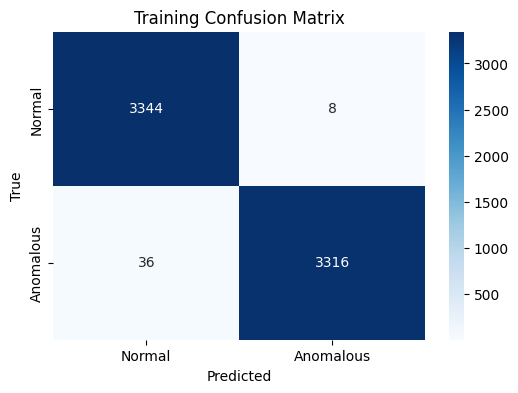


Metrics for Training Data:

Accuracy: 0.9934
Precision: 0.9976
Recall: 0.9893
F1-Score: 0.9934

Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      3352
   Anomalous       1.00      0.99      0.99      3352

    accuracy                           0.99      6704
   macro avg       0.99      0.99      0.99      6704
weighted avg       0.99      0.99      0.99      6704



In [92]:
# Get predictions and ground truth for training set
train_labels, train_preds = get_predictions(model, train_loader, device="cpu")

# Plot the confusion matrix for the training set
plot_confusion_matrix(train_labels, train_preds, title="Training Confusion Matrix")

# Compute and print metrics for the training set
print_classification_metrics(train_labels, train_preds, dataset_name="Training Data")

# get metrics for training set
train_metrics = compute_metrics(train_labels, train_preds)


### Visualization for Validation set

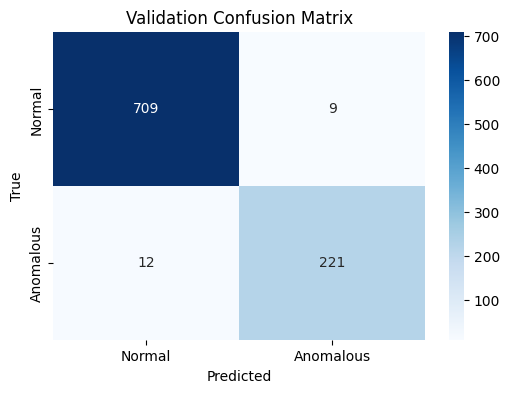


Metrics for Validation Data:

Accuracy: 0.9779
Precision: 0.9609
Recall: 0.9485
F1-Score: 0.9546

Classification Report:

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       718
   Anomalous       0.96      0.95      0.95       233

    accuracy                           0.98       951
   macro avg       0.97      0.97      0.97       951
weighted avg       0.98      0.98      0.98       951



In [93]:
# Get predictions and ground truth for validation set
val_labels, val_preds = get_predictions(model, val_loader, device="cpu")

# Plot the confusion matrix for the validation set
plot_confusion_matrix(val_labels, val_preds, title="Validation Confusion Matrix")

# Compute and print metrics for the validation set
print_classification_metrics(val_labels, val_preds, dataset_name="Validation Data")

# get metrics for validation set
val_metrics = compute_metrics(val_labels, val_preds)

### Visualization of Testing set

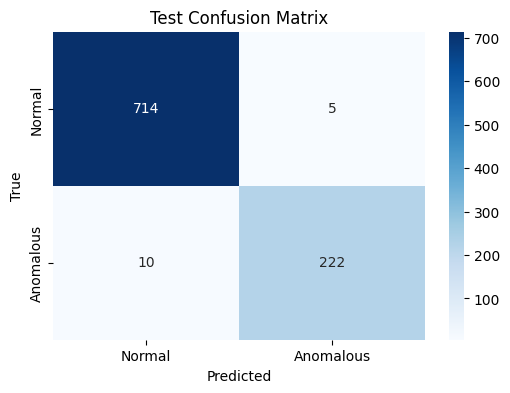


Metrics for Test Data:

Accuracy: 0.9842
Precision: 0.9780
Recall: 0.9569
F1-Score: 0.9673

Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       719
   Anomalous       0.98      0.96      0.97       232

    accuracy                           0.98       951
   macro avg       0.98      0.97      0.98       951
weighted avg       0.98      0.98      0.98       951



In [59]:
# Get predictions and ground truth for test set
test_labels, test_preds = get_predictions(model, test_loader, device="cpu")

# Plot the confusion matrix for the test set
plot_confusion_matrix(test_labels, test_preds, title="Test Confusion Matrix")

# Compute and print metrics for the test set
print_classification_metrics(test_labels, test_preds, dataset_name="Test Data")

# get metrics for test set
test_metrics = compute_metrics(test_labels, test_preds)


### Baseline Model Autoencoder Implementation

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_auc(y_true, y_scores, dataset_name="Dataset"):
    """
    Plot ROC-AUC curve for a given dataset.
    Args:
        y_true: Ground truth labels.
        y_scores: Model output probabilities (scores).
        dataset_name: Name of the dataset (e.g., Training or Test).
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")  # Random guess line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc="lower right")
    plt.show()

    print(f"AUC for {dataset_name}: {roc_auc:.4f}")


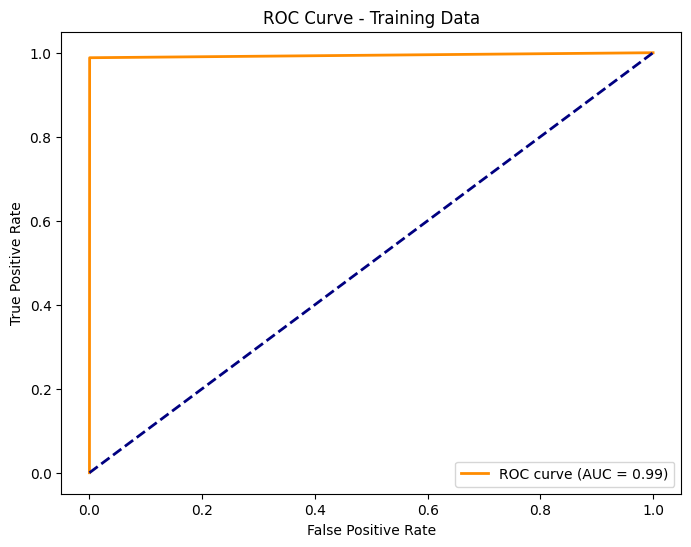

AUC for Training Data: 0.9939


In [61]:
# train_labels, train_scores = get_predictions(model, train_loader, device="cpu")
plot_roc_auc(train_labels, train_preds, dataset_name="Training Data")


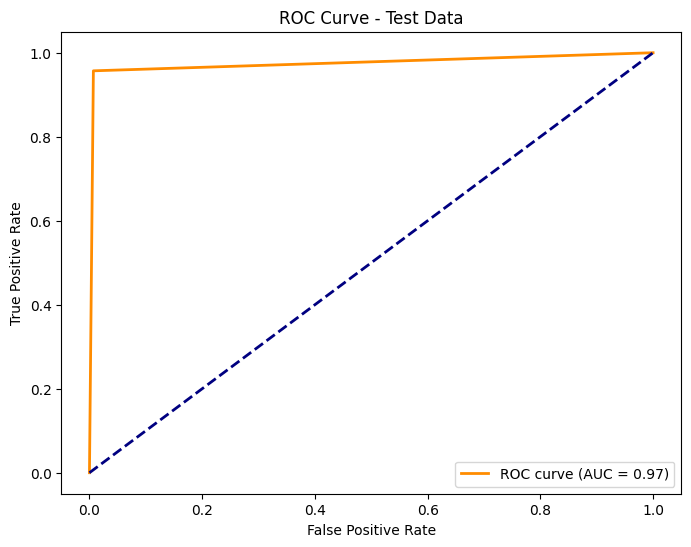

AUC for Test Data: 0.9750


In [62]:
# test_labels, test_scores = get_predictions(model, test_loader, device="cpu")
plot_roc_auc(test_labels, test_preds, dataset_name="Test Data")


### Comparing with base model, Autoencoder.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=3, stride=2, padding=1),  # Downsample
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=2, padding=1),  # Downsample
            nn.ReLU(),
            nn.Conv3d(64, 128, kernel_size=3, stride=2, padding=1),  # Downsample
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # Upsample
            nn.ReLU(),
            nn.ConvTranspose3d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # Upsample
            nn.ReLU(),
            nn.ConvTranspose3d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # Upsample
            nn.Sigmoid()  # Output normalized between [0, 1]
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


#### Training the model

In [5]:
def train_autoencoder(model, train_loader, optimizer, criterion, num_epochs=10, device="cpu"):
    model.to(device)
    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for sequences, _ in train_loader:  # Use only sequences; ignore labels
            sequences = sequences.to(device)

            optimizer.zero_grad()
            outputs = model(sequences)
            loss = criterion(outputs, sequences)  # Reconstruction loss
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch}/{num_epochs}, Loss: {running_loss / len(train_loader):.4f}")


Preparing the data for the autoencoder model

In [ ]:
def preprocess_frame(frame, target_size=(64, 64)):
    """
    Preprocess a single video frame: resize, normalize, and optionally reduce noise.
    """
    # Resize the frame
    resized_frame = cv2.resize(frame, target_size)
    
    # Normalize the pixel values to the range [0, 1]
    normalized_frame = resized_frame / 255.0

    # Optional: Apply Gaussian blur to reduce noise
    denoised_frame = cv2.GaussianBlur(normalized_frame, (5, 5), 0)

    return denoised_frame



def preprocess_sequence(sequence, target_size=(64, 64)):
    """
    Preprocess a sequence of video frames.
    """
    preprocessed_frames = [preprocess_frame(frame, target_size) for frame in sequence]
    return np.array(preprocessed_frames)




# Assuming sequences is a list of NumPy arrays, each representing a video sequence
preprocessed_sequences = [preprocess_sequence(sequence) for sequence in sequences]

# If you have labels, they remain unchanged
preprocessed_labels = labels


In [7]:
class VideoSequenceDataset(Dataset):
    def __init__(self, sequences, labels=None, target_size=(64, 64)):
        self.sequences = [preprocess_sequence(seq, target_size) for seq in sequences]
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.float32)
        sequence = sequence.permute(3, 0, 1, 2)  # [channels, sequence_length, height, width]

        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return sequence, label
        else:
            return sequence


In [11]:
# Assuming sequences and labels are loaded
preprocessed_sequences = [preprocess_sequence(seq) for seq in sequences]

# Create dataset and DataLoader
dataset = VideoSequenceDataset(preprocessed_sequences, labels)
loader = DataLoader(train_dataset, batch_size=4, shuffle=True)  # Reduced batch size
model = Autoencoder()


criterion = nn.MSELoss()  # Use Mean Squared Error for reconstruction
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Train the model
train_autoencoder(model, loader, optimizer, criterion, num_epochs=10, device="cpu")


Epoch 1/10, Loss: 0.0110
Epoch 2/10, Loss: 0.0042
Epoch 3/10, Loss: 0.0029
Epoch 4/10, Loss: 0.0024
Epoch 5/10, Loss: 0.0020
Epoch 6/10, Loss: 0.0018
Epoch 7/10, Loss: 0.0016
Epoch 8/10, Loss: 0.0015
Epoch 9/10, Loss: 0.0014
Epoch 10/10, Loss: 0.0013


Evaluating the model performance

In [16]:
def compute_reconstruction_error(model, data_loader, device="cpu"):
    model.eval()
    errors = []
    true_labels = []

    with torch.no_grad():
        for sequences, labels in data_loader:
            sequences = sequences.to(device)
            reconstructed = model(sequences)

            # Compute Mean Squared Error (MSE) per sequence
            error = ((reconstructed - sequences) ** 2).mean(dim=[1, 2, 3, 4])
            errors.extend(error.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return np.array(errors), np.array(true_labels)


In [ ]:
def find_optimal_threshold(errors, labels):
    precision, recall, thresholds = precision_recall_curve(labels, errors)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)  # Avoid division by zero
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx]


validation_errors, validation_labels = compute_reconstruction_error(model, val_loader)
optimal_threshold = find_optimal_threshold(validation_errors, validation_labels)
print(f"Optimal Threshold: {optimal_threshold}")


Optimal Threshold: 0.001625889795832336


In [19]:
def classify_anomalies(errors, threshold):
    return (errors > threshold).astype(int)  # 1 for anomaly, 0 for normal

# Example usage
test_errors, test_labels = compute_reconstruction_error(model, test_loader)
test_predictions = classify_anomalies(test_errors, optimal_threshold)


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_performance(true_labels, predicted_labels, errors):

    print(f"\nMetrics:\n")
    metrics = compute_metrics(true_labels, predicted_labels)
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    print("Classification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=["Normal", "Anomalous"]))

    roc_auc = roc_auc_score(true_labels, errors)
    print(f"ROC-AUC: {roc_auc:.4f}")
    # return roc_auc



In [ ]:
# Compute reconstruction errors
test_errors, test_labels = compute_reconstruction_error(model, test_loader)

# Determine threshold using validation set
validation_errors, validation_labels = compute_reconstruction_error(model, val_loader)
optimal_threshold = find_optimal_threshold(validation_errors, validation_labels)

# Classify anomalies in test set
test_predictions = classify_anomalies(test_errors, optimal_threshold)

# Evaluate performance
evaluate_performance(test_labels, test_predictions, test_errors)




Metrics:

Accuracy: 0.7382
Precision: 0.4491
Recall: 0.3233
F1-Score: 0.3759
Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      0.87      0.83       719
   Anomalous       0.45      0.32      0.38       232

    accuracy                           0.74       951
   macro avg       0.62      0.60      0.61       951
weighted avg       0.71      0.74      0.72       951

ROC-AUC: 0.5803


### Comparing the Models' Results

In [ ]:
# Metrics of STCN and Autoencoder
metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "STCN Model": [0.98, 0.97, 0.95, 0.97],  # Replace with actual STCN metrics
    "Autoencoder": [0.74, 0.45, 0.32, 0.38]  # Replace with actual Autoencoder metrics
}

# DataFrame for comparison
comparison_table = pd.DataFrame(metrics)

# Saving the table to a CSV file
comparison_table.to_csv("comparison_table.csv", index=False)

# Visualizing the comparison in a pretty table
print("\nMetrics comparition between models:\n")
print(tabulate(comparison_table, headers='keys', tablefmt='grid'))



Metrics comparition between models:

+----+-----------+--------------+---------------+
|    | Metric    |   STCN Model |   Autoencoder |
+====+===========+==============+===============+
|  0 | Accuracy  |         0.98 |          0.74 |
+----+-----------+--------------+---------------+
|  1 | Precision |         0.97 |          0.45 |
+----+-----------+--------------+---------------+
|  2 | Recall    |         0.95 |          0.32 |
+----+-----------+--------------+---------------+
|  3 | F1-Score  |         0.97 |          0.38 |
+----+-----------+--------------+---------------+
